# DistilBERT with MiCA

This notebook fine-tunes DistilBERT with [Minor Component Adaptation (MiCA)](https://arxiv.org/abs/2604.01694) on the [`rasbt/human-vs-ai-50k`](https://huggingface.co/datasets/rasbt/human-vs-ai-50k) dataset. It follows the same train, calibrate, evaluate, and export workflow as the LoRA notebook.

MiCA initializes one adapter matrix from the minor singular components of each pretrained weight matrix and trains only the other adapter matrix. The [PEFT documentation](https://huggingface.co/docs/peft/main/package_reference/lora) describes MiCA as primarily intended for continued pretraining and domain adaptation. This notebook applies it to sequence classification as a direct experimental comparison with the LoRA baseline.

From the project directory, install the dependencies with `uv sync --group dev` and open the notebook with `uv run jupyter lab scripts/08_distilbert-lora/distilbert-mica.ipynb`. The project pins a PEFT commit that includes MiCA because PEFT 0.19.1 does not yet implement this initializer.

In [1]:
import json
import platform
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import torch
import transformers
from datasets import load_dataset
from peft import (
    AutoPeftModelForSequenceClassification,
    LoraConfig,
    TaskType,
    get_peft_model,
)
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"PEFT version: {peft.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

PyTorch version: 2.13.0+cu130
Transformers version: 5.14.1
PEFT version: 0.20.0
Device: cuda


## Load the dataset

In [3]:
dataset = load_dataset("rasbt/human-vs-ai-50k")

train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'split', 'group_id', 'local_file', 'word_count', 'sha256', 'sample_type', 'text_collection', 'source_collection', 'source_document_id', 'source_name', 'source_title', 'source_url', 'source_license', 'source_license_url', 'source_authors', 'attribution_name', 'attribution_url', 'generator_provider', 'generator_model', 'seed_sample_id', 'target_words', 'public_hub_eligible'],
        num_rows: 40559
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'split', 'group_id', 'local_file', 'word_count', 'sha256', 'sample_type', 'text_collection', 'source_collection', 'source_document_id', 'source_name', 'source_title', 'source_url', 'source_license', 'source_license_url', 'source_authors', 'attribution_name', 'attribution_url', 'generator_provider', 'generator_model', 'seed_sample_id', 'target_words', 'public_hub_eligible'],
        num_rows: 5085
    })
    test: Dataset({
        features: ['

In [4]:
split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "human": split_dataset["label"].count(0),
            "ai": split_dataset["label"].count(1),
            "total": len(split_dataset),
        }
        for split_name, split_dataset in dataset.items()
    ]
).set_index("split")

split_summary

,human,ai,total
split,,,
train,20256,20303,40559
validation,2552,2533,5085
test,2547,2519,5066


## Tokenization

DistilBERT supports sequences of at most 512 tokens. Longer dataset samples are truncated to their first 512 tokens. Dynamic padding keeps shorter samples from being padded until a batch is assembled.

In [5]:
MODEL_NAME = "distilbert/distilbert-base-uncased"
MAX_LENGTH = 512
RANDOM_STATE = 17

set_seed(RANDOM_STATE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


columns_to_remove = [
    column
    for column in train_dataset.column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing",
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 40559
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5085
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5066
    })
})

## Add MiCA adapters

For a pretrained weight matrix $W = U \Sigma V^T$, MiCA initializes $B$ with the left singular vectors associated with the smallest singular values and initializes $A$ with zeros. The pretrained weights and $B$ stay frozen, while only $A$ is updated. The adapter is therefore a no-op before training.

The LoRA notebook uses rank 8 and a learning rate of `1e-4`. Here, I start with rank 4 and `2e-4`, following the practical MiCA rule of using about half the LoRA rank and twice its learning rate. The query and value projections are adapted in all six DistilBERT attention blocks. DistilBERT's `pre_classifier` and `classifier` layers are fully trained and saved because they are newly initialized for this classification task.

In [6]:
id2label = {0: "HUMAN", 1: "AI"}
label2id = {"HUMAN": 0, "AI": 1}

base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

MICA_RANK = 4
MICA_ALPHA = 8
MICA_DROPOUT = 0.1
MICA_TARGET_MODULES = ["q_lin", "v_lin"]
MODULES_TO_SAVE = ["pre_classifier", "classifier"]

mica_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=MICA_RANK,
    lora_alpha=MICA_ALPHA,
    lora_dropout=MICA_DROPOUT,
    target_modules=MICA_TARGET_MODULES,
    modules_to_save=MODULES_TO_SAVE,
    bias="none",
    init_lora_weights="mica",
)

model = get_peft_model(base_model, mica_config)

mica_a_parameters = [
    parameter
    for name, parameter in model.named_parameters()
    if "lora_A" in name
]
mica_b_parameters = [
    parameter
    for name, parameter in model.named_parameters()
    if "lora_B" in name
]

assert mica_a_parameters and mica_b_parameters
assert all(parameter.requires_grad for parameter in mica_a_parameters)
assert all(not parameter.requires_grad for parameter in mica_b_parameters)
assert all(
    torch.count_nonzero(parameter).item() == 0
    for parameter in mica_a_parameters
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
total_parameters = sum(
    parameter.numel() for parameter in model.parameters()
)
trainable_mica_parameters = sum(
    parameter.numel() for parameter in mica_a_parameters
)
frozen_mica_basis_parameters = sum(
    parameter.numel() for parameter in mica_b_parameters
)

model.print_trainable_parameters()
print(f"Trainable MiCA A parameters: {trainable_mica_parameters:,}")
print(f"Frozen MiCA B parameters: {frozen_mica_basis_parameters:,}")
print(
    "Share trainable: "
    f"{trainable_parameters / total_parameters:.2%}"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 628,994 || all params: 67,620,868 || trainable%: 0.9302
Trainable MiCA A parameters: 36,864
Frozen MiCA B parameters: 36,864
Share trainable: 0.93%


## Fine-tuning

The MiCA A matrices and classification head are trained only on the training split. Validation accuracy selects the best epoch, and early stopping ends training if validation accuracy stops improving. The validation split is subsequently reused for temperature scaling, while the test split remains untouched until the final evaluation.

In [7]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}


use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

training_args = TrainingArguments(
    output_dir="checkpoints-mica",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,
    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,
    report_to="none",
    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

In [8]:
train_result = trainer.train()

print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"Best validation accuracy: {trainer.state.best_metric:.2%}")
print(
    "Training time: "
    f"{train_result.metrics['train_runtime'] / 60:.1f} minutes"
)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.042046,0.034486,0.988397
2,0.016999,0.017456,0.994690
3,0.010933,0.017760,0.994494


Best checkpoint: checkpoints-mica/checkpoint-5070
Best validation accuracy: 99.47%
Training time: 13.4 minutes


## Temperature scaling

Temperature scaling learns one positive scalar from the validation logits. Dividing the logits by this temperature changes the confidence of the predictions without changing which class has the larger logit. A temperature above 1 softens the probabilities, while a temperature below 1 makes them more confident.

In [9]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)
validation_logits = np.asarray(validation_output.predictions)
y_validation = np.asarray(
    validation_dataset["label"], dtype=np.int64
)


def fit_temperature(logits, labels):
    logits_tensor = torch.tensor(logits, dtype=torch.float64)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    log_temperature = torch.nn.Parameter(
        torch.zeros((), dtype=torch.float64)
    )
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        temperature = log_temperature.exp()
        loss = criterion(logits_tensor / temperature, labels_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(log_temperature.exp().detach())


def probabilities_from_logits(logits, temperature=1.0):
    scaled_logits = np.asarray(logits, dtype=np.float64) / temperature
    scaled_logits -= scaled_logits.max(axis=1, keepdims=True)
    exponentiated = np.exp(scaled_logits)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)


TEMPERATURE = fit_temperature(validation_logits, y_validation)
print(f"Learned temperature: {TEMPERATURE:.4f}")

Learned temperature: 1.5534


In [10]:
uncalibrated_validation_probability = probabilities_from_logits(
    validation_logits
)[:, 1]
calibrated_validation_probability = probabilities_from_logits(
    validation_logits, TEMPERATURE
)[:, 1]

calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",
            "Brier score": brier_score_loss(
                y_validation, uncalibrated_validation_probability
            ),
            "Log loss": log_loss(
                y_validation, uncalibrated_validation_probability
            ),
        },
        {
            "model": "Temperature-scaled",
            "Brier score": brier_score_loss(
                y_validation, calibrated_validation_probability
            ),
            "Log loss": log_loss(
                y_validation, calibrated_validation_probability
            ),
        },
    ]
).set_index("model")

calibration_comparison.style.format("{:.4f}")

,Brier score,Log loss
model,,
Uncalibrated,0.0043,0.0175
Temperature-scaled,0.0042,0.0153


## Final evaluation

The following results use the temperature-scaled probabilities with a decision threshold of 0.5. Training results are fit-set diagnostics, while validation results reuse the checkpoint-selection and calibration set. The test split provides the final held-out evaluation.

The positive class is AI-generated text. A false positive is human text classified as AI, and a false negative is AI-generated text classified as human.

In [11]:
DECISION_THRESHOLD = 0.5

split_logits = {"validation": validation_logits}
for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )
    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def evaluate_split(split_name):
    y_true = np.asarray(dataset[split_name]["label"], dtype=np.int64)
    ai_probability = probabilities_from_logits(
        split_logits[split_name], TEMPERATURE
    )[:, 1]
    y_pred = (
        ai_probability >= DECISION_THRESHOLD
    ).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, ai_probability),
        "log_loss": log_loss(y_true, ai_probability),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")

evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,true_negative,false_positive,false_negative,true_positive
split,,,,,,,
train,99.52%,0.0038,0.0143,20098,158,35,20268
validation,99.47%,0.0042,0.0153,2535,17,10,2523
test,99.43%,0.0051,0.0196,2528,19,10,2509


## Test-set confusion matrix

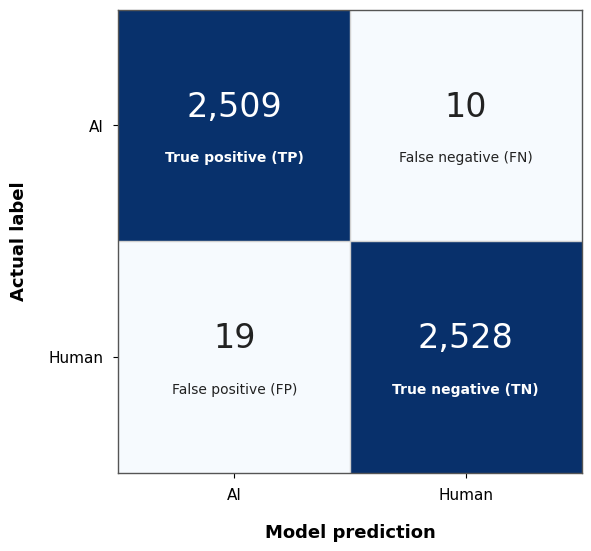

In [12]:
y_test = np.asarray(test_dataset["label"], dtype=np.int64)
y_test_ai_probability = probabilities_from_logits(
    split_logits["test"], TEMPERATURE
)[:, 1]
y_test_pred = (
    y_test_ai_probability >= DECISION_THRESHOLD
).astype(np.int64)

# AI is listed first so the matrix reads TP, FN, FP, TN.
test_matrix = confusion_matrix(
    y_test, y_test_pred, labels=[1, 0]
)
cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(test_matrix, cmap="Blues", vmin=0, vmax=test_matrix.max())

for row in range(2):
    for column in range(2):
        value = test_matrix[row, column]
        text_color = (
            "white" if value > test_matrix.max() / 2 else "#222222"
        )
        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )
        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
            fontweight=(
                "bold"
                if value > test_matrix.max() / 2
                else "normal"
            ),
        )

ax.set_xticks([0, 1], labels=["AI", "Human"])
ax.set_yticks([0, 1], labels=["AI", "Human"])
ax.set_xlabel(
    "Model prediction", fontsize=13, fontweight="bold", labelpad=15
)
ax.set_ylabel(
    "Actual label", fontsize=13, fontweight="bold", labelpad=15
)
ax.axhline(0.5, color="#d0d0d0", linewidth=1)
ax.axvline(0.5, color="#d0d0d0", linewidth=1)
ax.tick_params(axis="both", labelsize=11, pad=7)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()
plt.savefig("distilbert-mica-confmat.svg")
plt.show()

## Inspect confident test-set errors

This table makes it easier to check whether the model relies on dataset artifacts or struggles with particular text sources. The confidence column is the probability assigned to the predicted class.

In [13]:
test_errors = pd.DataFrame(
    {
        "id": test_dataset["id"],
        "actual": np.where(y_test == 1, "AI", "Human"),
        "prediction": np.where(y_test_pred == 1, "AI", "Human"),
        "ai_probability": y_test_ai_probability,
        "source_collection": test_dataset["source_collection"],
        "generator_model": test_dataset["generator_model"],
        "text": [text[:300] for text in test_dataset["text"]],
    }
)
test_errors = test_errors[
    test_errors["actual"] != test_errors["prediction"]
].copy()
test_errors["prediction_confidence"] = np.where(
    test_errors["prediction"] == "AI",
    test_errors["ai_probability"],
    1.0 - test_errors["ai_probability"],
)

test_errors.sort_values(
    "prediction_confidence", ascending=False
).head(20).style.format(
    {
        "ai_probability": "{:.2%}",
        "prediction_confidence": "{:.2%}",
    }
)

,id,actual,prediction,ai_probability,source_collection,generator_model,text,prediction_confidence
3625,36153,AI,Human,0.29%,gutenberg,deepseek-v4-flash-0731,"In the 1995 Congress, Kansas’s Pat Roberts (RHOB, Rayburn) and Sam Brownback (RHOB) served alongside Kentucky’s Jim Bunning (RHOB) and Scotty Baesler (LHOB, Longworth). Also from Kentucky, Harold Rogers used RHOB, while Ron Lewis, who took office in 1994, had LHOB.",99.71%
2270,22921,Human,AI,99.58%,wikimedia,None,"Rugosodon most resemble those of multituberculates of the Late Jurassic of Western Europe, suggesting that Europe and Asia had extensive mammal faunal interchanges (hence the specific name, eurasia) during the Jurassic. Prior to the discovery of Rugosodon, scientists knew that multituberculates livi",99.58%
859,8650,Human,AI,99.28%,wikimedia,None,"David Rose is a fictional character in the Canadian sitcom Schitt's Creek, which aired on the CBC and Pop TV from 2015 to 2020. David, a member of the central Rose family, is introduced as the spoiled adult son of Johnny and Moira Rose, and the older brother of Alexis Rose. His initial stories revol",99.28%
1650,16593,Human,AI,98.85%,openstax,None,"of her fifteenth college reunion, she surveyed her graduating class about their lives. Their feelings of unfulfillment as stay-at-home wives and mothers provided the inspiration for The Feminine Mystique. The goal of the book was to empower fellow college-educated women to seek fulfilling careers ou",98.85%
865,8690,Human,AI,98.84%,wikimedia,None,"In baseball, a breaking ball is a pitch that does not travel straight as it approaches the batter; it will have sideways or downward motion on it, sometimes both (see slider). A breaking ball is not a specific pitch by that name, but is any pitch that ""breaks"", such as a curveball, slider, or screwb",98.84%
2150,21594,Human,AI,98.06%,wikimedia,None,"In compiler theory, dead-code elimination (also known as DCE, dead-code removal, dead-code stripping, or dead-code strip) is a compiler optimization to remove code which does not affect the program results. Removing such code has several benefits: it shrinks program size, an important consideration",98.06%
2307,23187,Human,AI,97.71%,wikimedia,None,"The 2013/14 season saw Walsall finish 13th in League One. The campaign was most notable for the Saddlers' meetings with Black Country rivals Wolves, including a 1–0 away at Molineux. The summer of 2013 saw the Saddlers lose the attacking trio of Will Grigg, Febian Brandy and Jamie Paterson, who had",97.71%
2839,28296,AI,Human,3.49%,arxiv,qwen3.6:35b,"The provided text does not contain specific acknowledgments or names of individuals who contributed comments on the analysis of SARS-CoV-2 variant contagiousness. Therefore, no list can be extracted from the current context to identify those acknowledged for their valuable input on this particular a",96.51%
2782,27735,AI,Human,3.66%,pmc,qwen3.6:35b,"The provided text does not contain the specific primer sequences for ACTB or RPLP0, nor does it detail the exact replication strategy used in the PCR analysis. Consequently, I cannot identify the nucleotide sequences for these nuclear reference genes from the given information. Similarly, the distin",96.34%
3379,33790,AI,Human,4.89%,wikimedia,deepseek-v4-flash-0731,"Ra McGuire and Brian Smith played in the late-1960s Vancouver band The Chessmen. That group recorded two singles on the Rumble Records label: ""I Can't Get Through to You"" (released in 1966) and ""I Need Your Lovin'"" (from 1967). The Chessmen were a prominent local garage-rock act before McGuire and S",95.11%


## Export the calibrated adapter

The exported directory contains the MiCA adapter, trained classification head, tokenizer, learned temperature, decision threshold, and package versions. The pretrained DistilBERT base weights remain external and are loaded from the base model repository during inference. Loading this adapter requires a PEFT version that supports `init_lora_weights="mica"`.

In [14]:
ARTIFACT_DIR = Path("artifacts") / "distilbert-mica-ai-detector"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(ARTIFACT_DIR)
tokenizer.save_pretrained(ARTIFACT_DIR)

metadata = {
    "dataset": "rasbt/human-vs-ai-50k",
    "base_model": MODEL_NAME,
    "label_mapping": {"human": 0, "ai": 1},
    "max_length": MAX_LENGTH,
    "decision_threshold": DECISION_THRESHOLD,
    "calibration": "temperature scaling",
    "temperature": TEMPERATURE,
    "best_validation_accuracy": float(trainer.state.best_metric),
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "random_state": RANDOM_STATE,
    "mica": {
        "initializer": "mica",
        "rank": MICA_RANK,
        "alpha": MICA_ALPHA,
        "dropout": MICA_DROPOUT,
        "target_modules": MICA_TARGET_MODULES,
        "modules_to_save": MODULES_TO_SAVE,
        "trainable_mica_parameters": trainable_mica_parameters,
        "frozen_mica_basis_parameters": frozen_mica_basis_parameters,
        "trainable_parameters": trainable_parameters,
        "total_parameters": total_parameters,
    },
    "python_version": platform.python_version(),
    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "peft",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}

METADATA_PATH = ARTIFACT_DIR / "detector-config.json"
METADATA_PATH.write_text(
    json.dumps(metadata, indent=2) + "\n",
    encoding="utf-8",
)

print(f"Saved adapter and tokenizer to {ARTIFACT_DIR}")
print(f"Saved detector configuration to {METADATA_PATH}")

Saved adapter and tokenizer to artifacts/distilbert-mica-ai-detector
Saved detector configuration to artifacts/distilbert-mica-ai-detector/detector-config.json


## Load the adapter in a script

The PEFT loader reads the adapter configuration, reconstructs the DistilBERT base classifier, and loads the MiCA and classification-head weights. The helper then applies the saved temperature to return calibrated AI probabilities.

In [15]:
loaded_tokenizer = AutoTokenizer.from_pretrained(ARTIFACT_DIR)
loaded_model = AutoPeftModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)
loaded_config = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

if torch.cuda.is_available():
    inference_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    inference_device = torch.device("mps")
else:
    inference_device = torch.device("cpu")

loaded_model.to(inference_device)
loaded_model.eval()


def predict_ai_probability(texts):
    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    ).to(inference_device)
    with torch.inference_mode():
        logits = loaded_model(**inputs).logits
        calibrated_logits = logits / loaded_config["temperature"]
        return calibrated_logits.softmax(dim=1)[:, 1].cpu().numpy()


texts = ["Replace this string with the text you want to classify."]
ai_probabilities = predict_ai_probability(texts)

for text, ai_probability in zip(texts, ai_probabilities):
    prediction = int(
        ai_probability >= loaded_config["decision_threshold"]
    )
    label = "AI" if prediction == 1 else "Human"
    print(f"{label}: {ai_probability:.1%} AI probability | {text}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AI: 82.6% AI probability | Replace this string with the text you want to classify.
